# **Résolution du MCKP avec l'algorithme génétique**









#Méthode de génération d'une instance

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# On génère une instance du problème
def generation_instance(n, m) : # n est le nombre de groupes et m le nombre d'objets par groupe
  groupes = []
  for i in range(n):
        groupe = []
        for j in range(m):
            profit = random.randint(10, 100)
            poids = random.randint(5, 20)
            groupe.append((profit, poids))
        groupes.append(groupe)
  capacite = sum([random.randint(5, 20) for _ in range(n)])
  return groupes, capacite

#Méthode de génération d'un individu aléatoire

In [ ]:
def individu_aleatoire(n,m) :
    return [random.randint(0, m - 1) for _ in range(n)]

# Exemple d'un individu : (1, 5, 6, 10, 6) --> 1er objet de la classe 1, 5ème objet de la classe 2, etc.

#Test

In [ ]:
n = 5  # 5 groupes
m = 10 # 10 objets par groupe

# A. On crée le problème (une seule fois)
mes_donnees_groupes, ma_capacite_max = generation_instance(n, m)

# B. On crée un individu
mon_individu = individu_aleatoire(n, m)

print(f"L'individu a fait les choix suivants : {mon_individu}")

# C. On regarde le "catalogue" pour voir ce que ça vaut :
profit_du_premier_choix = mes_donnees_groupes[0][mon_individu[0]][0] # Profit du groupe 0, objet choisi
print(f"Profit du premier objet choisi : {profit_du_premier_choix}")

L'individu a fait les choix suivants : [8, 5, 9, 1, 4]
Profit du premier objet choisi : 56


In [ ]:
def evaluer_fitness(individu, groupes, capacite):
    profit_total = 0
    poids_total = 0

    # Parcours des gènes de l'individu
    for i in range(len(individu)):
        objet_choisi_index = individu[i]
        profit, poids = groupes[i][objet_choisi_index]

        profit_total += profit
        poids_total += poids

    # Gestion de la contrainte de capacité
    if poids_total > capacite:
        # On calcule le dépassement
        depassement = poids_total - capacite
        # On applique une pénalité
        penalite = depassement * 10
        fitness = profit_total - penalite
    else:
        # Solution valide, la fitness est juste le profit
        fitness = profit_total

    return fitness, profit_total, poids_total

#Population initiale

In [ ]:
# Exemple d'une population de taille 3 : [(1, 5, 6, 10, 6), (5, 4, 3, 9, 0), (2, 4, 7, 1, 3)]

def population_initiale(taille_pop, n, m) :
    # Crée une liste contenant 'taille_pop' individus
    return [individu_aleatoire(n, m) for _ in range(taille_pop)]

# Test de la fonction
taille_pop = 50
population = population_initiale(taille_pop, n, m)
print(f"Exemple du premier individu de la population : {population[0]}")

Exemple du premier individu de la population : [9, 2, 4, 7, 4]


#Sélection par tournoi

In [ ]:
def selection_tournoi(population, groupes, capacite, taille_tournoi=3):
    meilleur_individu = None
    meilleure_fitness = -float('inf')

    # On choisit 'taille_tournoi' individus au hasard
    participants = random.sample(population, taille_tournoi)

    for participant in participants:
        fitness, _, _ = evaluer_fitness(participant, groupes, capacite)
        if fitness > meilleure_fitness:
            meilleure_fitness = fitness
            meilleur_individu = participant

    return meilleur_individu

#Croisement

In [ ]:
# Croisement en un point
def croisement_1_point(parent1, parent2):

    taille = len(parent1)

    # On choisit un point de coupure entre l'indice 1 et la fin
    # Si taille = 5, le point sera 1, 2, 3 ou 4.
    point_coupure = random.randint(1, taille - 1)

    # Création des enfants par concaténation de listes
    enfant1 = parent1[:point_coupure] + parent2[point_coupure:]
    enfant2 = parent2[:point_coupure] + parent1[point_coupure:]

    return enfant1, enfant2

In [ ]:
# Croisement en deux points
def croisement_2_points(parent1, parent2):

    taille = len(parent1)

    # On choisit deux points de coupure différents au hasard, puis on les trie
    point1, point2 = sorted(random.sample(range(1, taille), 2))

    # Enfant 1: Début P1 + Milieu P2 + Fin P1
    enfant1 = parent1[:point1] + parent2[point1:point2] + parent1[point2:]

    # Enfant 2: Début P2 + Milieu P1 + Fin P2
    enfant2 = parent2[:point1] + parent1[point1:point2] + parent2[point2:]

    return enfant1, enfant2

#Mutation

In [ ]:
# Mutation
def mutation(individu, proba_mutation, m):

    individu_mute = individu.copy()
    for i in range(len(individu_mute)):
        if random.random() < proba_mutation:
            # On remplace le choix par un autre objet du même groupe (entre 0 et m-1)
            individu_mute[i] = random.randint(0, m - 1)
    return individu_mute

# Boucle de l'algorithme génétique

In [ ]:
# AG 1
def algorithme_genetique_1(groupes, capacite, taille_pop=50, nb_generations=100, pc=0.8, pm=0.05, taille_tournoi=3):
    """
    Exécute l'Algorithme Génétique standard pour le MCKP.
    pc : Probabilité de croisement (ex: 0.8 pour 80%)
    pm : Probabilité de mutation (ex: 0.05 pour 5%)
    """
    n = len(groupes)
    m = len(groupes[0])

    # 1. Initialisation
    population = population_initiale(taille_pop, n, m)

    meilleur_individu_global = None
    meilleure_fitness_globale = -float('inf')
    historique_fitness = []

    # 2. Boucle des générations
    for generation in range(nb_generations):

        # --- ÉVALUATION ---
        for individu in population:
            fitness, profit, poids = evaluer_fitness(individu, groupes, capacite)

            # Mise à jour de la meilleure solution trouvée à ce jour
            if fitness > meilleure_fitness_globale:
                meilleure_fitness_globale = fitness
                meilleur_individu_global = individu.copy()

        # On sauvegarde la meilleure fitness de cette génération pour le graphique
        historique_fitness.append(meilleure_fitness_globale)

        # --- REPRODUCTION ---
        nouvelle_population = []

        # On garde le meilleur individu intact
        nouvelle_population.append(meilleur_individu_global)

        # On remplit le reste de la nouvelle population
        while len(nouvelle_population) < taille_pop:

            # A. Sélection
            parent1 = selection_tournoi(population, groupes, capacite, taille_tournoi)
            parent2 = selection_tournoi(population, groupes, capacite, taille_tournoi)

            # B. Croisement (on utilise le croisement en 1 point ici)
            if random.random() < pc:
                enfant1, enfant2 = croisement_1_point(parent1, parent2)
            else:
                enfant1, enfant2 = parent1.copy(), parent2.copy()

            # C. Mutation
            enfant1 = mutation(enfant1, pm, m)
            enfant2 = mutation(enfant2, pm, m)

            # D. Ajout à la nouvelle population
            nouvelle_population.append(enfant1)
            # On vérifie qu'on ne dépasse pas la taille de la population
            if len(nouvelle_population) < taille_pop:
                nouvelle_population.append(enfant2)

        # Remplacement de l'ancienne population par la nouvelle
        population = nouvelle_population

    # Fin de l'algorithme, on renvoie les résultats
    return meilleur_individu_global, meilleure_fitness_globale, historique_fitness

In [ ]:
# AG 2 : Même algorithme sauf qu'on utilise le croisement en deux points

def algorithme_genetique_2(groupes, capacite, taille_pop=50, nb_generations=100, pc=0.8, pm=0.05, taille_tournoi=3):

    n = len(groupes)
    m = len(groupes[0])

    population = population_initiale(taille_pop, n, m)

    meilleur_individu_global = None
    meilleure_fitness_globale = -float('inf')
    historique_fitness = []

    for generation in range(nb_generations):

        for individu in population:
            fitness, profit, poids = evaluer_fitness(individu, groupes, capacite)

            if fitness > meilleure_fitness_globale:
                meilleure_fitness_globale = fitness
                meilleur_individu_global = individu.copy()

        historique_fitness.append(meilleure_fitness_globale)

        nouvelle_population = []

        nouvelle_population.append(meilleur_individu_global)

        while len(nouvelle_population) < taille_pop:

            parent1 = selection_tournoi(population, groupes, capacite, taille_tournoi)
            parent2 = selection_tournoi(population, groupes, capacite, taille_tournoi)

            if random.random() < pc:
                enfant1, enfant2 = croisement_2_points(parent1, parent2)
            else:
                enfant1, enfant2 = parent1.copy(), parent2.copy()

            enfant1 = mutation(enfant1, pm, m)
            enfant2 = mutation(enfant2, pm, m)

            nouvelle_population.append(enfant1)

            if len(nouvelle_population) < taille_pop:
                nouvelle_population.append(enfant2)

        population = nouvelle_population

    return meilleur_individu_global, meilleure_fitness_globale, historique_fitness

#Résultats

Capacité fixée pour le test : 98
Exécution de l'AG 1 (1 point)...
Exécution de l'AG 2 (2 points)...


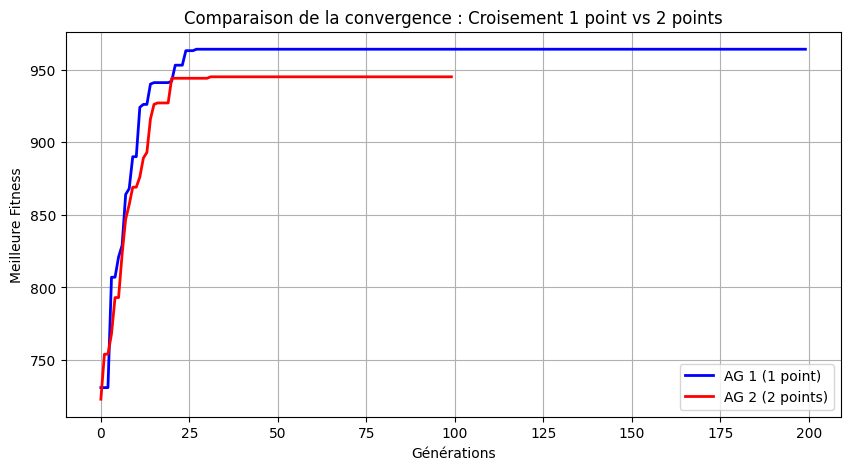

Fitness finale AG 1 : 964
Fitness finale AG 2 : 945


In [ ]:
# 1. Génération de l'instance unique
n = 10
m = 20
groupes_communs, capacite_commune = generation_instance(n, m)

print(f"Capacité fixée pour le test : {capacite_commune}")

# 2. Exécution de l'algorithme 1 (Croisement 1 point)
print("Exécution de l'AG 1 (1 point)...")
meilleur_ind_1, meilleure_fit_1, historique_1 = algorithme_genetique_1(
    groupes=groupes_communs,
    capacite=capacite_commune,
    taille_pop=100,
    nb_generations=200
)

# 3. Exécution de l'algorithme 2 (Croisement 2 points)
print("Exécution de l'AG 2 (2 points)...")
meilleur_ind_2, meilleure_fit_2, historique_2 = algorithme_genetique_2(
    groupes=groupes_communs,
    capacite=capacite_commune,
    taille_pop=50,
    nb_generations=100
)

# 4. Comparaison visuelle
plt.figure(figsize=(10, 5))
plt.plot(historique_1, color='blue', label='AG 1 (1 point)', linewidth=2)
plt.plot(historique_2, color='red', label='AG 2 (2 points)', linewidth=2)

plt.title("Comparaison de la convergence : Croisement 1 point vs 2 points")
plt.xlabel("Générations")
plt.ylabel("Meilleure Fitness")
plt.legend()
plt.grid(True)
plt.show()

print(f"Fitness finale AG 1 : {meilleure_fit_1}")
print(f"Fitness finale AG 2 : {meilleure_fit_2}")

# **Intégration du machine learning**

In [ ]:
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier

def algorithme_genetique_hybride_classification(groupes, capacite, taille_pop=50, nb_generations=100, pc=0.8, pm=0.05, taille_tournoi=3, gen_apprentissage=20):
    """
    Algorithme Génétique amélioré par un classifieur (Random Forest).
    Le modèle apprend pendant 'gen_apprentissage' générations, puis filtre les mauvais enfants.
    """
    n = len(groupes)
    m = len(groupes[0])

    # 1. Initialisation
    population = population_initiale(taille_pop, n, m)
    meilleur_individu_global = None
    meilleure_fitness_globale = -float('inf')
    historique_fitness = []

    # Variables pour le Machine Learning
    X_data = [] # Stockera les individus
    y_fitness = [] # Stockera les fitness pour calculer la médiane

    # On choisit le Random Forest
    clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    modele_entraine = False

    # 2. Boucle des générations
    for generation in range(nb_generations):

        # --- ÉVALUATION ---
        for individu in population:
            fitness, profit, poids = evaluer_fitness(individu, groupes, capacite)

            # Collecte des données pour le Machine Learning
            if not modele_entraine:
                X_data.append(individu.copy())
                y_fitness.append(fitness)

            # Mise à jour du meilleur individu
            if fitness > meilleure_fitness_globale:
                meilleure_fitness_globale = fitness
                meilleur_individu_global = individu.copy()

        historique_fitness.append(meilleure_fitness_globale)

        # --- APPRENTISSAGE DU MODÈLE ---
        if generation == gen_apprentissage and not modele_entraine:
            print(f"Entraînement du modèle de Machine Learning à la génération {generation} sur {len(X_data)} exemples")
            # On transforme les fitness en classes : 1 (Prometteur) / 0 (Médiocre)
            mediane = np.median(y_fitness)
            y_class = [1 if f >= mediane else 0 for f in y_fitness]

            # Entraînement du classifieur
            clf.fit(X_data, y_class)
            modele_entraine = True

        # --- REPRODUCTION ---
        nouvelle_population = []
        nouvelle_population.append(meilleur_individu_global.copy()) # Élitisme

        # Boucle de création des enfants
        tentatives = 0 # Sécurité pour éviter les boucles infinies
        while len(nouvelle_population) < taille_pop:
            tentatives += 1

            parent1 = selection_tournoi(population, groupes, capacite, taille_tournoi)
            parent2 = selection_tournoi(population, groupes, capacite, taille_tournoi)

            if random.random() < pc:
                enfant1, enfant2 = croisement_1_point(parent1, parent2)
            else:
                enfant1, enfant2 = parent1.copy(), parent2.copy()

            enfant1 = mutation(enfant1, pm, m)
            enfant2 = mutation(enfant2, pm, m)

            # --- FILTRE MACHINE LEARNING ---
            if modele_entraine:
                candidats = [enfant1, enfant2]
                for enfant in candidats:
                    if len(nouvelle_population) >= taille_pop:
                        break

                    # On prédit la classe de l'enfant
                    prediction = clf.predict([enfant])[0]

                    # On l'accepte s'il est prédit "Bon" (1) OU si on force l'exploration
                    # L'exploration forcée évite que l'algorithme ne s'enferme dans un optimum local
                    if prediction == 1 or random.random() < 0.10:
                        nouvelle_population.append(enfant)
                        tentatives = 0 # Reset des tentatives après un succès

                # Si le modèle est trop sévère et rejette tout, on force l'ajout au bout de 50 essais
                if tentatives > 50:
                    nouvelle_population.append(enfant1)
                    tentatives = 0
            else:
                # Si le modèle n'est pas encore entraîné, on fonctionne normalement
                nouvelle_population.append(enfant1)
                if len(nouvelle_population) < taille_pop:
                    nouvelle_population.append(enfant2)

        population = nouvelle_population

    return meilleur_individu_global, meilleure_fitness_globale, historique_fitness

#Résultats

Capacité du sac pour le test : 1247
--------------------------------------------------
Exécution de l'Algorithme Génétique Classique
 Stratégie tirée au sort : Algorithme 1 (Croisement en 1 point)
-> Terminé en 38.39 secondes. Fitness finale : 8998
--------------------------------------------------
Exécution de l'Algorithme Génétique Hybride (Random Forest)
Entraînement du modèle de Machine Learning à la génération 100 sur 50500 exemples
Terminé en 11281.56 secondes. Fitness finale : 9059
--------------------------------------------------


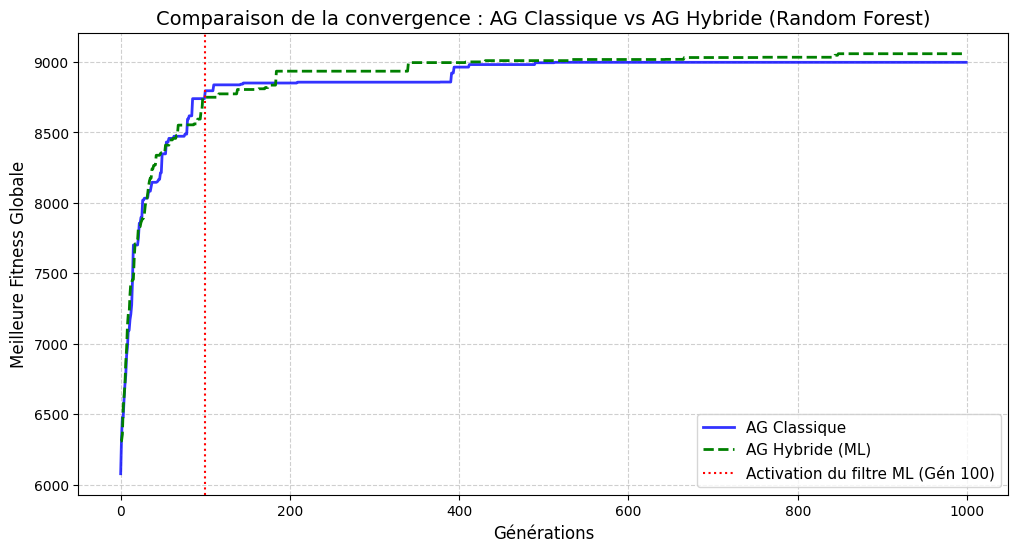

In [ ]:
import time

# 1. Génération de l'instance unique
n_groupes = 100
m_objets = 200
groupes_test, capacite_test = generation_instance(n_groupes, m_objets)

print(f"Capacité du sac pour le test : {capacite_test}")
print("-" * 50)

# 2. Exécution de l'algorithme classique
print("Exécution de l'Algorithme Génétique Classique")
start_time_classique = time.time()

# Implémentation du choix 50/50
if random.random() < 0.5:
    print(" Stratégie tirée au sort : Algorithme 1 (Croisement en 1 point)")
    meilleur_ind_classique, meilleure_fit_classique, historique_classique = algorithme_genetique_1(
        groupes=groupes_test,
        capacite=capacite_test,
        taille_pop=500,
        nb_generations=1000,
        pc=0.8,
        pm=0.05
    )
else:
    print("Stratégie tirée au sort : Algorithme 2 (Croisement en 2 points)")
    meilleur_ind_classique, meilleure_fit_classique, historique_classique = algorithme_genetique_2(
        groupes=groupes_test,
        capacite=capacite_test,
        taille_pop=500,
        nb_generations=1000,
        pc=0.8,
        pm=0.05
    )

temps_classique = time.time() - start_time_classique
print(f"-> Terminé en {temps_classique:.2f} secondes. Fitness finale : {meilleure_fit_classique}")
print("-" * 50)

# 3. Exécution de l'algorithme hybride (avec Machine Learning)
print("Exécution de l'Algorithme Génétique Hybride (Random Forest)")
start_time_hybride = time.time()
meilleur_ind_hybride, meilleure_fit_hybride, historique_hybride = algorithme_genetique_hybride_classification(
    groupes=groupes_test,
    capacite=capacite_test,
    taille_pop=500,
    nb_generations=1000,
    pc=0.8,
    pm=0.05,
    gen_apprentissage=100 # Le modèle apprend sur les 50 premières générations
)
temps_hybride = time.time() - start_time_hybride
print(f"Terminé en {temps_hybride:.2f} secondes. Fitness finale : {meilleure_fit_hybride}")
print("-" * 50)

# 4. Comparaison visuelle
plt.figure(figsize=(12, 6))

# Tracé des deux courbes
plt.plot(historique_classique, color='blue', label='AG Classique', linewidth=2, alpha=0.8)
plt.plot(historique_hybride, color='green', label='AG Hybride (ML)', linewidth=2, linestyle='--')

# Ligne verticale pour indiquer quand le ML s'active
plt.axvline(x=100, color='red', linestyle=':', label='Activation du filtre ML (Gén 100)')

plt.title("Comparaison de la convergence : AG Classique vs AG Hybride (Random Forest)", fontsize=14)
plt.xlabel("Générations", fontsize=12)
plt.ylabel("Meilleure Fitness Globale", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()